# США: проверка гипотезы о сравнительной роли инфляционных ожиданий и фактической инфляции

В этом ноутбуке строится отдельная модель для США, с помощью которой можно сравнить влияние
фактической инфляции и инфляционных ожиданий на доходность **S&P 500**.

Логика построения:
1. загружаются данные по индексу и макрофакторам США;
2. данные переводятся в месячную частоту;
3. рассчитываются преобразованные переменные;
4. все объясняющие переменные лагируются на один месяц;
5. оцениваются три вложенные модели на **одной и той же общей выборке**:
   - модель с фактической инфляцией;
   - модель с инфляционными ожиданиями;
   - модель, где обе переменные включены одновременно;
6. отдельно строится квартальная robustness-проверка.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"

DATA_XLSX = DATA_DIR / "data.xlsx"
DATAMFS_XLSX = DATA_DIR / "datamfs.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "usa_h2_model_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_XLSX:", DATA_XLSX)
print("DATAMFS_XLSX:", DATAMFS_XLSX)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: C:\Users\ggwpn\OneDrive\Desktop\Diplom
DATA_XLSX: C:\Users\ggwpn\OneDrive\Desktop\Diplom\data\data.xlsx
DATAMFS_XLSX: C:\Users\ggwpn\OneDrive\Desktop\Diplom\data\datamfs.xlsx
OUTPUT_DIR: C:\Users\ggwpn\OneDrive\Desktop\Diplom\usa_h2_model_outputs


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Загрузка данных

In [3]:
prices_raw = pd.read_excel(DATA_XLSX, sheet_name="static", parse_dates=["Dates"])
us_raw = pd.read_excel(DATAMFS_XLSX, sheet_name="US", parse_dates=["Dates"])

prices_raw = prices_raw.set_index("Dates").sort_index()
us_raw = us_raw.set_index("Dates").sort_index()

print("Диапазон по индексам:", prices_raw.index.min().date(), "-", prices_raw.index.max().date())
print("Диапазон по US макроданным:", us_raw.index.min().date(), "-", us_raw.index.max().date())
print()
print("Колонки индексов:")
print(prices_raw.columns.tolist())
print()
print("Колонки US-листа:")
print(us_raw.columns.tolist())

Диапазон по индексам: 1985-01-23 - 2025-01-23
Диапазон по US макроданным: 1985-01-29 - 2025-01-29

Колонки индексов:
['SPX Index', 'SX5E Index', 'UKX Index', 'DAX Index', 'CAC Index', 'NKY Index', 'HSI Index', 'AS51 Index', 'NIFTY Index']

Колонки US-листа:
['GT10 Govt', 'GT2 Govt', 'FDTR Index', 'GT5 Govt', 'GTII05 Govt', 'CPI YOY  Index', 'CPI XYOY Index', 'IP Index', 'GDP CQOQ Index', 'USURTOT Index', 'REALAHRE Index', 'FDDSGDP Index', 'USTBTOT  Index', 'GDPUNSA  Index']


## 2. Построение месячного датасета

Основная модель оценивается на месячной частоте. Это позволяет:
- использовать достаточно длинную выборку;
- сохранить рыночный прокси инфляционных ожиданий;
- не смешивать месячные и квартальные ряды внутри основной спецификации.

В качестве инфляционных ожиданий используется **5-летний breakeven inflation**:

\[
\pi^e_t = y^{(5)}_t - y^{(5, TIPS)}_t,
\]

где \( y^{(5)}_t \) — доходность 5-летних обычных государственных облигаций США,
а \( y^{(5, TIPS)}_t \) — доходность 5-летних инфляционно-защищённых облигаций.

Все объясняющие переменные лагируются на один месяц, чтобы уменьшить проблему одновременности.

In [4]:
prices_m = prices_raw["SPX Index"].resample("ME").last()
us_m = us_raw.resample("ME").last()

monthly = pd.DataFrame(index=prices_m.index)
monthly["spx_return"] = np.log(prices_m).diff() * 100
monthly["spx_return_lag1"] = monthly["spx_return"].shift(1)

monthly["term_spread"] = us_m["GT10 Govt"] - us_m["GT2 Govt"]
monthly["policy_rate_change"] = us_m["FDTR Index"].diff()

monthly["actual_inflation"] = us_m["CPI YOY  Index"]
monthly["inflation_expectations"] = us_m["GT5 Govt"] - us_m["GTII05 Govt"]

monthly["ip_growth_yoy"] = (np.log(us_m["IP Index"]) - np.log(us_m["IP Index"].shift(12))) * 100
monthly["unemployment_change"] = us_m["USURTOT Index"].diff()

predictors = [
    "term_spread",
    "policy_rate_change",
    "actual_inflation",
    "inflation_expectations",
    "ip_growth_yoy",
    "unemployment_change",
]

for col in predictors:
    monthly[f"{col}_lag1"] = monthly[col].shift(1)

monthly.head(15)

,spx_return,spx_return_lag1,term_spread,policy_rate_change,actual_inflation,inflation_expectations,ip_growth_yoy,unemployment_change,term_spread_lag1,policy_rate_change_lag1,actual_inflation_lag1,inflation_expectations_lag1,ip_growth_yoy_lag1,unemployment_change_lag1
Dates,,,,,,,,,,,,,,
1985-01-31,NaN,NaN,1.256,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-02-28,0.859183,NaN,1.243,0.75,3.5,NaN,NaN,-0.1,1.256,NaN,3.5,NaN,NaN,NaN
1985-03-31,-0.287420,0.859183,1.207,-0.50,3.5,NaN,NaN,0.0,1.243,0.75,3.5,NaN,NaN,-0.1
1985-04-30,-0.460485,-0.287420,1.486,-0.25,3.7,NaN,NaN,0.1,1.207,-0.50,3.5,NaN,NaN,0.0
1985-05-31,5.264088,-0.460485,1.391,-0.50,3.8,NaN,NaN,-0.1,1.486,-0.25,3.7,NaN,NaN,0.1
1985-06-30,1.206097,5.264088,1.566,0.00,3.8,NaN,NaN,0.0,1.391,-0.50,3.8,NaN,NaN,-0.1
1985-07-31,-0.485932,1.206097,1.522,0.00,3.6,NaN,NaN,0.2,1.566,0.00,3.8,NaN,NaN,0.0
1985-08-31,-1.206707,-0.485932,1.313,0.25,3.6,NaN,NaN,0.0,1.522,0.00,3.6,NaN,NaN,0.2
1985-09-30,-3.534127,-1.206707,1.421,0.00,3.1,NaN,NaN,-0.3,1.313,0.25,3.6,NaN,NaN,0.0


In [5]:
sample_info = pd.DataFrame({
    "start": monthly.notna().idxmax(),
    "end": monthly.apply(lambda x: x.dropna().index.max()),
    "non_missing_obs": monthly.notna().sum(),
})
sample_info

,start,end,non_missing_obs
spx_return,1985-02-28,2025-01-31,480
spx_return_lag1,1985-03-31,2025-01-31,479
term_spread,1985-01-31,2025-01-31,481
policy_rate_change,1985-02-28,2025-01-31,480
actual_inflation,1985-01-31,2025-01-31,481
inflation_expectations,1997-07-31,2025-01-31,331
ip_growth_yoy,1986-01-31,2025-01-31,469
unemployment_change,1985-02-28,2025-01-31,480
term_spread_lag1,1985-02-28,2025-01-31,480
policy_rate_change_lag1,1985-03-31,2025-01-31,479


### Почему используется общая выборка

Серия рыночных инфляционных ожиданий начинается позже, чем ряд фактической инфляции.
Поэтому для корректного сравнения моделей с фактической инфляцией и инфляционными ожиданиями
ниже используется **один и тот же общий временной интервал** — тот, на котором доступны обе переменные.

In [6]:
common_monthly_cols = [
    "spx_return",
    "spx_return_lag1",
    "term_spread_lag1",
    "policy_rate_change_lag1",
    "actual_inflation_lag1",
    "inflation_expectations_lag1",
    "ip_growth_yoy_lag1",
    "unemployment_change_lag1",
]

monthly_common = monthly[common_monthly_cols].dropna().copy()

print("Общая месячная выборка:")
print(monthly_common.index.min().date(), "-", monthly_common.index.max().date())
print("Число наблюдений:", len(monthly_common))
monthly_common.head()

Общая месячная выборка:
1997-08-31 - 2025-01-31
Число наблюдений: 330


,spx_return,spx_return_lag1,term_spread_lag1,policy_rate_change_lag1,actual_inflation_lag1,inflation_expectations_lag1,ip_growth_yoy_lag1,unemployment_change_lag1
Dates,,,,,,,,
1997-08-31,-5.916191,7.522178,0.283,0.0,2.2,2.310,6.538246,-0.1
1997-09-30,5.178902,-5.916191,0.384,0.0,2.2,2.627,6.538246,0.0
1997-10-31,-3.508604,5.178902,0.324,0.0,2.2,2.298,7.336024,0.0
1997-11-30,4.362142,-3.508604,0.219,0.0,2.1,2.135,8.244504,-0.2
1997-12-31,1.560917,4.362142,0.136,0.0,2.1,2.274,8.244504,0.0


## 3. Предварительный анализ

In [7]:
descriptive_stats = monthly_common.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
spx_return,330.0,0.561467,4.506046,-18.563649,-1.838400,1.138417,3.488814,11.942090
spx_return_lag1,330.0,0.573892,4.519590,-18.563649,-1.838400,1.138417,3.506534,11.942090
term_spread_lag1,330.0,0.992200,0.967708,-1.060000,0.175500,0.942000,1.852500,2.808000
policy_rate_change_lag1,330.0,-0.003030,0.216156,-1.500000,0.000000,0.000000,0.000000,0.750000
actual_inflation_lag1,330.0,2.528788,1.719879,-2.100000,1.600000,2.200000,3.300000,9.100000
inflation_expectations_lag1,330.0,1.952809,0.548685,-0.339000,1.614750,2.015500,2.329500,3.371000
ip_growth_yoy_lag1,330.0,1.020354,4.550372,-19.016496,-0.527003,2.023068,3.557442,15.811032
unemployment_change_lag1,330.0,-0.002727,0.647106,-3.800000,-0.100000,0.000000,0.000000,10.400000


In [8]:
corr_matrix = monthly_common.corr()
corr_matrix

,spx_return,spx_return_lag1,term_spread_lag1,policy_rate_change_lag1,actual_inflation_lag1,inflation_expectations_lag1,ip_growth_yoy_lag1,unemployment_change_lag1
spx_return,1.000000,0.003199,-0.017892,0.032930,-0.152078,-0.044722,-0.004079,0.029563
spx_return_lag1,0.003199,1.000000,-0.033888,0.093392,-0.150205,0.103804,0.003276,0.061923
term_spread_lag1,-0.017892,-0.033888,1.000000,-0.193131,-0.369739,-0.210318,-0.166912,-0.009668
policy_rate_change_lag1,0.032930,0.093392,-0.193131,1.000000,0.222622,0.366020,0.202070,-0.080461
actual_inflation_lag1,-0.152078,-0.150205,-0.369739,0.222622,1.000000,0.596205,0.375565,-0.057691
inflation_expectations_lag1,-0.044722,0.103804,-0.210318,0.366020,0.596205,1.000000,0.514714,-0.157156
ip_growth_yoy_lag1,-0.004079,0.003276,-0.166912,0.202070,0.375565,0.514714,1.000000,-0.235548
unemployment_change_lag1,0.029563,0.061923,-0.009668,-0.080461,-0.057691,-0.157156,-0.235548,1.000000


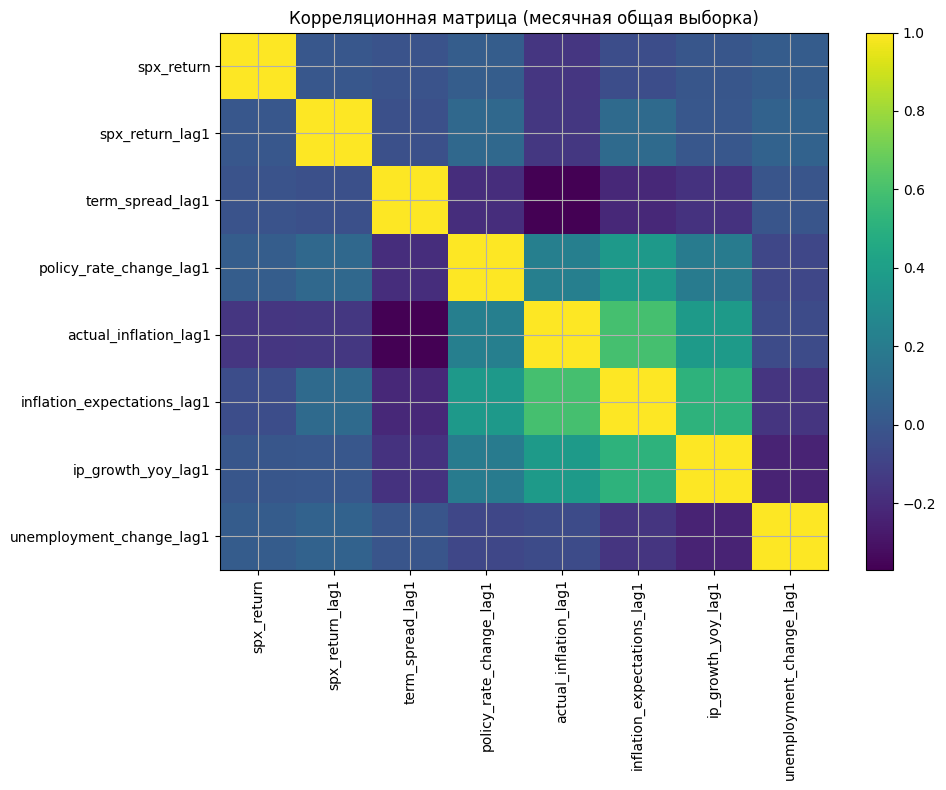

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)
fig.colorbar(im, ax=ax)
ax.set_title("Корреляционная матрица (месячная общая выборка)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

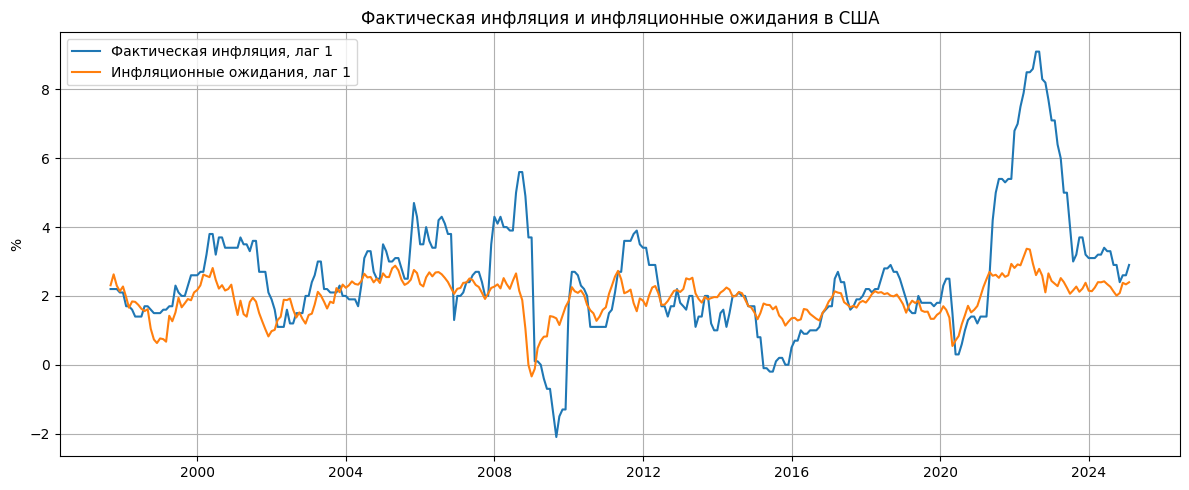

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_common.index, monthly_common["actual_inflation_lag1"], label="Фактическая инфляция, лаг 1")
ax.plot(monthly_common.index, monthly_common["inflation_expectations_lag1"], label="Инфляционные ожидания, лаг 1")
ax.set_title("Фактическая инфляция и инфляционные ожидания в США")
ax.set_ylabel("%")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inflation_vs_expectations.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
adf_rows = []
for col in monthly_common.columns:
    s = monthly_common[col].dropna()
    adf_stat, pvalue, usedlag, nobs, crit_vals, icbest = adfuller(s)
    adf_rows.append({
        "variable": col,
        "adf_stat": adf_stat,
        "pvalue": pvalue,
        "used_lags": usedlag,
        "nobs": nobs,
        "crit_1%": crit_vals["1%"],
        "crit_5%": crit_vals["5%"],
        "crit_10%": crit_vals["10%"],
    })

adf_table = pd.DataFrame(adf_rows).set_index("variable")
adf_table

,adf_stat,pvalue,used_lags,nobs,crit_1%,crit_5%,crit_10%
variable,,,,,,,
spx_return,-17.949215,2.842554e-30,0,329,-3.450384,-2.870365,-2.571472
spx_return_lag1,-9.953223,2.482869e-17,2,327,-3.450507,-2.870420,-2.571501
term_spread_lag1,-2.951378,3.969134e-02,8,321,-3.450887,-2.870586,-2.571590
policy_rate_change_lag1,-3.941785,1.747971e-03,5,324,-3.450695,-2.870502,-2.571545
actual_inflation_lag1,-3.543887,6.928985e-03,17,312,-3.451484,-2.870849,-2.571730
inflation_expectations_lag1,-4.574438,1.439320e-04,1,328,-3.450445,-2.870392,-2.571486
ip_growth_yoy_lag1,-4.129495,8.653331e-04,17,312,-3.451484,-2.870849,-2.571730
unemployment_change_lag1,-11.410656,7.264329e-21,3,326,-3.450569,-2.870447,-2.571515


## 4. Оценка месячных моделей

Оцениваются три вложенные модели с HAC / Newey–West стандартными ошибками.

### Модель M1
Доходность S&P 500 объясняется фактической инфляцией и набором контрольных переменных.

### Модель M2
Доходность S&P 500 объясняется инфляционными ожиданиями и тем же набором контролей.

### Модель M3
В модель одновременно включаются и фактическая инфляция, и инфляционные ожидания.

In [12]:
MONTHLY_MODEL_SPECS = {
    "M1_actual_inflation": [
        "spx_return_lag1",
        "term_spread_lag1",
        "policy_rate_change_lag1",
        "actual_inflation_lag1",
        "ip_growth_yoy_lag1",
        "unemployment_change_lag1",
    ],
    "M2_inflation_expectations": [
        "spx_return_lag1",
        "term_spread_lag1",
        "policy_rate_change_lag1",
        "inflation_expectations_lag1",
        "ip_growth_yoy_lag1",
        "unemployment_change_lag1",
    ],
    "M3_both_inflation_measures": [
        "spx_return_lag1",
        "term_spread_lag1",
        "policy_rate_change_lag1",
        "actual_inflation_lag1",
        "inflation_expectations_lag1",
        "ip_growth_yoy_lag1",
        "unemployment_change_lag1",
    ],
}

def fit_hac_ols(df, y_col, x_cols, hac_lags=3):
    y = df[y_col]
    X = sm.add_constant(df[x_cols], has_constant="add")
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    fitted = pd.Series(res.fittedvalues, index=df.index, name="fitted")
    resid = pd.Series(res.resid, index=df.index, name="resid")
    return res, fitted, resid

monthly_results = {}
monthly_fitted = pd.DataFrame(index=monthly_common.index)

for model_name, xcols in MONTHLY_MODEL_SPECS.items():
    res, fitted, resid = fit_hac_ols(monthly_common, "spx_return", xcols, hac_lags=3)
    monthly_results[model_name] = {"result": res, "fitted": fitted, "resid": resid, "xcols": xcols}
    monthly_fitted[model_name] = fitted

In [13]:
for model_name in MONTHLY_MODEL_SPECS:
    print("=" * 120)
    print(model_name)
    print(monthly_results[model_name]["result"].summary())
    print()

M1_actual_inflation
                            OLS Regression Results                            
Dep. Variable:             spx_return   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     2.697
Date:                Sun, 10 May 2026   Prob (F-statistic):             0.0144
Time:                        23:43:57   Log-Likelihood:                -958.14
No. Observations:                 330   AIC:                             1930.
Df Residuals:                     323   BIC:                             1957.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
cons

In [14]:
comparison_rows = []
for model_name, pack in monthly_results.items():
    res = pack["result"]
    comparison_rows.append({
        "model": model_name,
        "nobs": int(res.nobs),
        "adj_r2": res.rsquared_adj,
        "aic": res.aic,
        "bic": res.bic,
        "dw": sm.stats.stattools.durbin_watson(res.resid),
        "ljung_box_pvalue_lag6": acorr_ljungbox(res.resid, lags=[6], return_df=True)["lb_pvalue"].iloc[0],
    })

monthly_model_comparison = pd.DataFrame(comparison_rows).set_index("model").sort_values("aic")
monthly_model_comparison

,nobs,adj_r2,aic,bic,dw,ljung_box_pvalue_lag6
model,,,,,,
M1_actual_inflation,330,0.020157,1930.281532,1956.875181,1.989529,0.391240
M3_both_inflation_measures,330,0.018646,1931.766947,1962.159688,1.991519,0.318314
M2_inflation_expectations,330,-0.012043,1940.951724,1967.545372,1.980491,0.464257


In [15]:
coef_rows = []
for model_name, pack in monthly_results.items():
    res = pack["result"]
    for var in res.params.index:
        coef_rows.append({
            "model": model_name,
            "variable": var,
            "coef": res.params[var],
            "std_err": res.bse[var],
            "pvalue": res.pvalues[var],
            "t_or_z": res.tvalues[var],
        })

monthly_coef_table = pd.DataFrame(coef_rows)
monthly_coef_table.head(20)

,model,variable,coef,std_err,pvalue,t_or_z
0,M1_actual_inflation,const,2.364702,0.587066,0.000056,4.027998
1,M1_actual_inflation,spx_return_lag1,-0.041098,0.060603,0.497670,-0.678160
2,M1_actual_inflation,term_spread_lag1,-0.366998,0.263396,0.163519,-1.393334
3,M1_actual_inflation,policy_rate_change_lag1,1.280814,1.703765,0.452199,0.751755
4,M1_actual_inflation,actual_inflation_lag1,-0.583152,0.179475,0.001157,-3.249207
5,M1_actual_inflation,ip_growth_yoy_lag1,0.062490,0.077916,0.422541,0.802021
6,M1_actual_inflation,unemployment_change_lag1,0.266841,0.191901,0.164373,1.390513
7,M2_inflation_expectations,const,1.899630,1.295930,0.142691,1.465843
8,M2_inflation_expectations,spx_return_lag1,0.003921,0.067958,0.953992,0.057695
9,M2_inflation_expectations,term_spread_lag1,-0.087761,0.239397,0.713925,-0.366590


In [16]:
# Стандартизированные коэффициенты
def zscore_df(df):
    return (df - df.mean()) / df.std(ddof=0)

std_rows = []
for model_name, xcols in MONTHLY_MODEL_SPECS.items():
    zdf = zscore_df(monthly_common[["spx_return"] + xcols].dropna())
    zres, _, _ = fit_hac_ols(zdf, "spx_return", xcols, hac_lags=3)
    for var in xcols:
        std_rows.append({
            "model": model_name,
            "variable": var,
            "std_coef": zres.params[var],
            "pvalue": zres.pvalues[var],
        })

monthly_std_coef = pd.DataFrame(std_rows)
monthly_std_coef

,model,variable,std_coef,pvalue
0,M1_actual_inflation,spx_return_lag1,-0.041222,0.497670
1,M1_actual_inflation,term_spread_lag1,-0.078816,0.163519
2,M1_actual_inflation,policy_rate_change_lag1,0.061441,0.452199
3,M1_actual_inflation,actual_inflation_lag1,-0.222579,0.001157
4,M1_actual_inflation,ip_growth_yoy_lag1,0.063105,0.422541
5,M1_actual_inflation,unemployment_change_lag1,0.038321,0.164373
6,M2_inflation_expectations,spx_return_lag1,0.003933,0.953992
7,M2_inflation_expectations,term_spread_lag1,-0.018847,0.713925
8,M2_inflation_expectations,policy_rate_change_lag1,0.054422,0.495615
9,M2_inflation_expectations,inflation_expectations_lag1,-0.079755,0.278113


In [17]:
# VIF только для модели, где обе инфляционные переменные стоят вместе
X_vif = sm.add_constant(monthly_common[MONTHLY_MODEL_SPECS["M3_both_inflation_measures"]], has_constant="add")
vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_table

,variable,VIF
0,const,21.710969
1,spx_return_lag1,1.112673
2,term_spread_lag1,1.193952
3,policy_rate_change_lag1,1.179840
4,actual_inflation_lag1,1.887479
5,inflation_expectations_lag1,2.096887
6,ip_growth_yoy_lag1,1.428621
7,unemployment_change_lag1,1.076212


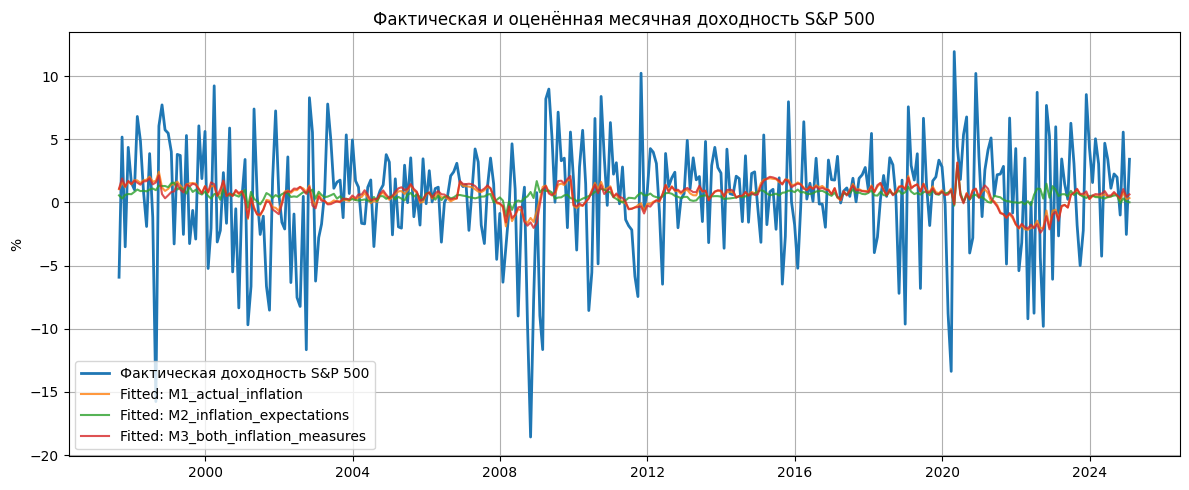

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_common.index, monthly_common["spx_return"], label="Фактическая доходность S&P 500", linewidth=2)
for model_name in monthly_fitted.columns:
    ax.plot(monthly_fitted.index, monthly_fitted[model_name], label=f"Fitted: {model_name}", alpha=0.8)
ax.set_title("Фактическая и оценённая месячная доходность S&P 500")
ax.set_ylabel("%")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_actual_vs_fitted.png", dpi=150, bbox_inches="tight")
plt.show()

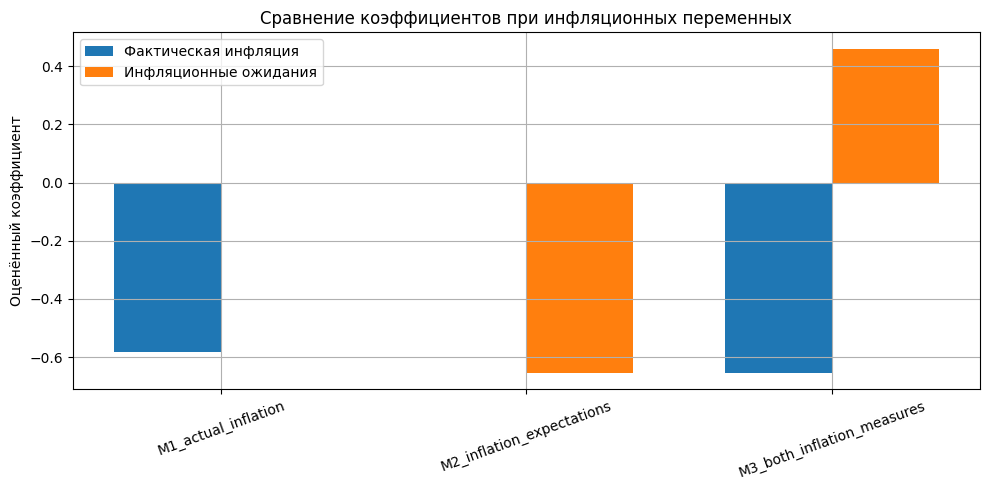

In [19]:
inflation_compare = monthly_coef_table[
    monthly_coef_table["variable"].isin(["actual_inflation_lag1", "inflation_expectations_lag1"])
].copy()

pivot_infl = inflation_compare.pivot(index="model", columns="variable", values="coef")
pivot_infl = pivot_infl.reindex(MONTHLY_MODEL_SPECS.keys())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot_infl.index))
width = 0.35

actual_vals = pivot_infl.get("actual_inflation_lag1", pd.Series(index=pivot_infl.index, dtype=float)).fillna(0).values
exp_vals = pivot_infl.get("inflation_expectations_lag1", pd.Series(index=pivot_infl.index, dtype=float)).fillna(0).values

ax.bar(x - width/2, actual_vals, width=width, label="Фактическая инфляция")
ax.bar(x + width/2, exp_vals, width=width, label="Инфляционные ожидания")

ax.set_xticks(x)
ax.set_xticklabels(pivot_infl.index, rotation=20)
ax.set_title("Сравнение коэффициентов при инфляционных переменных")
ax.set_ylabel("Оценённый коэффициент")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_inflation_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Квартальная robustness-проверка

Чтобы дополнительно проверить устойчивость результатов, ниже строится более компактная квартальная версия модели.
В неё добавляется квартальный рост ВВП, а все объясняющие переменные также берутся с лагом в один квартал.

Этот блок не заменяет основную месячную модель, а служит дополнительной проверкой.

In [20]:
prices_q = prices_raw["SPX Index"].resample("QE").last()
us_q = us_raw.resample("QE").last()

quarterly = pd.DataFrame(index=prices_q.index)
quarterly["spx_return"] = np.log(prices_q).diff() * 100
quarterly["spx_return_lag1"] = quarterly["spx_return"].shift(1)

quarterly["term_spread"] = us_q["GT10 Govt"] - us_q["GT2 Govt"]
quarterly["policy_rate_change"] = us_q["FDTR Index"].diff()
quarterly["actual_inflation"] = us_q["CPI YOY  Index"]
quarterly["inflation_expectations"] = us_q["GT5 Govt"] - us_q["GTII05 Govt"]
quarterly["ip_growth_yoy"] = (np.log(us_q["IP Index"]) - np.log(us_q["IP Index"].shift(4))) * 100
quarterly["gdp_growth"] = us_q["GDP CQOQ Index"]

q_predictors = [
    "term_spread",
    "policy_rate_change",
    "actual_inflation",
    "inflation_expectations",
    "ip_growth_yoy",
    "gdp_growth",
]
for col in q_predictors:
    quarterly[f"{col}_lag1"] = quarterly[col].shift(1)

common_quarterly_cols = [
    "spx_return",
    "spx_return_lag1",
    "term_spread_lag1",
    "policy_rate_change_lag1",
    "actual_inflation_lag1",
    "inflation_expectations_lag1",
    "ip_growth_yoy_lag1",
    "gdp_growth_lag1",
]

quarterly_common = quarterly[common_quarterly_cols].dropna().copy()

print("Общая квартальная выборка:")
print(quarterly_common.index.min().date(), "-", quarterly_common.index.max().date())
print("Число наблюдений:", len(quarterly_common))
quarterly_common.head()

Общая квартальная выборка:
1997-12-31 - 2025-03-31
Число наблюдений: 110


,spx_return,spx_return_lag1,term_spread_lag1,policy_rate_change_lag1,actual_inflation_lag1,inflation_expectations_lag1,ip_growth_yoy_lag1,gdp_growth_lag1
Dates,,,,,,,,
1997-12-31,2.414455,6.784890,0.324,0.00,2.2,2.298,7.336024,5.1
1998-03-31,12.691583,2.414455,0.096,0.00,1.7,1.965,7.954989,3.5
1998-06-30,2.871028,12.691583,0.091,0.00,1.4,1.827,6.644908,4.1
1998-09-30,-10.874315,2.871028,-0.025,0.00,1.7,1.559,5.940291,3.8
1998-12-31,18.952101,-10.874315,0.147,-0.25,1.5,0.734,4.725609,5.1


In [21]:
QUARTERLY_MODEL_SPECS = {
    "Q1_actual_inflation": [
        "spx_return_lag1",
        "term_spread_lag1",
        "policy_rate_change_lag1",
        "actual_inflation_lag1",
        "ip_growth_yoy_lag1",
        "gdp_growth_lag1",
    ],
    "Q2_inflation_expectations": [
        "spx_return_lag1",
        "term_spread_lag1",
        "policy_rate_change_lag1",
        "inflation_expectations_lag1",
        "ip_growth_yoy_lag1",
        "gdp_growth_lag1",
    ],
    "Q3_both_inflation_measures": [
        "spx_return_lag1",
        "term_spread_lag1",
        "policy_rate_change_lag1",
        "actual_inflation_lag1",
        "inflation_expectations_lag1",
        "ip_growth_yoy_lag1",
        "gdp_growth_lag1",
    ],
}

quarterly_results = {}
for model_name, xcols in QUARTERLY_MODEL_SPECS.items():
    res, fitted, resid = fit_hac_ols(quarterly_common, "spx_return", xcols, hac_lags=2)
    quarterly_results[model_name] = {"result": res, "fitted": fitted, "resid": resid, "xcols": xcols}

quarterly_comp_rows = []
for model_name, pack in quarterly_results.items():
    res = pack["result"]
    quarterly_comp_rows.append({
        "model": model_name,
        "nobs": int(res.nobs),
        "adj_r2": res.rsquared_adj,
        "aic": res.aic,
        "bic": res.bic,
        "dw": sm.stats.stattools.durbin_watson(res.resid),
        "ljung_box_pvalue_lag4": acorr_ljungbox(res.resid, lags=[4], return_df=True)["lb_pvalue"].iloc[0],
    })

quarterly_model_comparison = pd.DataFrame(quarterly_comp_rows).set_index("model").sort_values("aic")
quarterly_model_comparison

,nobs,adj_r2,aic,bic,dw,ljung_box_pvalue_lag4
model,,,,,,
Q1_actual_inflation,110,0.050174,783.709575,802.612937,2.015105,0.963773
Q3_both_inflation_measures,110,0.044364,785.307195,806.911038,2.031851,0.982992
Q2_inflation_expectations,110,0.006614,788.642023,807.545386,2.077255,0.987294


In [22]:
for model_name in QUARTERLY_MODEL_SPECS:
    print("=" * 120)
    print(model_name)
    print(quarterly_results[model_name]["result"].summary())
    print()

Q1_actual_inflation
                            OLS Regression Results                            
Dep. Variable:             spx_return   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     2.079
Date:                Sun, 10 May 2026   Prob (F-statistic):             0.0619
Time:                        23:43:58   Log-Likelihood:                -384.85
No. Observations:                 110   AIC:                             783.7
Df Residuals:                     103   BIC:                             802.6
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

In [23]:
quarterly_coef_rows = []
for model_name, pack in quarterly_results.items():
    res = pack["result"]
    for var in res.params.index:
        quarterly_coef_rows.append({
            "model": model_name,
            "variable": var,
            "coef": res.params[var],
            "std_err": res.bse[var],
            "pvalue": res.pvalues[var],
            "t_or_z": res.tvalues[var],
        })

quarterly_coef_table = pd.DataFrame(quarterly_coef_rows)
quarterly_coef_table.head(20)

,model,variable,coef,std_err,pvalue,t_or_z
0,Q1_actual_inflation,const,6.797669,1.875266,0.000289,3.624909
1,Q1_actual_inflation,spx_return_lag1,-0.087588,0.110835,0.429377,-0.790257
2,Q1_actual_inflation,term_spread_lag1,-0.962929,0.821284,0.241009,-1.172467
3,Q1_actual_inflation,policy_rate_change_lag1,2.773186,1.634718,0.089804,1.696430
4,Q1_actual_inflation,actual_inflation_lag1,-1.718627,0.583412,0.003221,-2.945818
5,Q1_actual_inflation,ip_growth_yoy_lag1,0.062219,0.246766,0.800935,0.252138
6,Q1_actual_inflation,gdp_growth_lag1,0.123532,0.124129,0.319643,0.995192
7,Q2_inflation_expectations,const,9.406083,3.271153,0.004034,2.875465
8,Q2_inflation_expectations,spx_return_lag1,0.034295,0.115535,0.766590,0.296838
9,Q2_inflation_expectations,term_spread_lag1,-0.112294,0.808355,0.889516,-0.138917


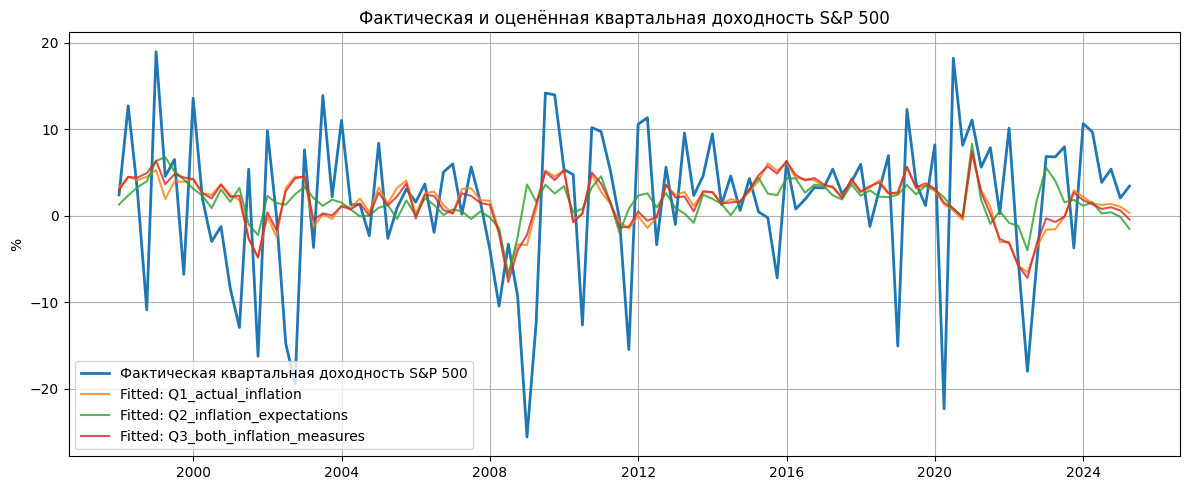

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(quarterly_common.index, quarterly_common["spx_return"], label="Фактическая квартальная доходность S&P 500", linewidth=2)
for model_name, pack in quarterly_results.items():
    ax.plot(pack["fitted"].index, pack["fitted"], label=f"Fitted: {model_name}", alpha=0.8)
ax.set_title("Фактическая и оценённая квартальная доходность S&P 500")
ax.set_ylabel("%")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quarterly_actual_vs_fitted.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Сохранение таблиц результатов

In [25]:
with pd.ExcelWriter(OUTPUT_DIR / "usa_h2_results.xlsx", engine="openpyxl") as writer:
    sample_info.to_excel(writer, sheet_name="sample_info")
    descriptive_stats.to_excel(writer, sheet_name="monthly_descriptive")
    corr_matrix.to_excel(writer, sheet_name="monthly_corr")
    adf_table.to_excel(writer, sheet_name="monthly_adf")
    monthly_model_comparison.to_excel(writer, sheet_name="monthly_model_cmp")
    monthly_coef_table.to_excel(writer, sheet_name="monthly_coefficients", index=False)
    monthly_std_coef.to_excel(writer, sheet_name="monthly_std_coefficients", index=False)
    vif_table.to_excel(writer, sheet_name="monthly_vif", index=False)
    monthly_common.to_excel(writer, sheet_name="monthly_dataset")
    pd.concat([monthly_common["spx_return"], monthly_fitted], axis=1).to_excel(writer, sheet_name="monthly_fitted")
    quarterly_model_comparison.to_excel(writer, sheet_name="quarterly_model_cmp")
    quarterly_coef_table.to_excel(writer, sheet_name="quarterly_coefficients", index=False)
    quarterly_common.to_excel(writer, sheet_name="quarterly_dataset")

print("Файл результатов сохранён:", OUTPUT_DIR / "usa_h2_results.xlsx")

Файл результатов сохранён: C:\Users\ggwpn\OneDrive\Desktop\Diplom\usa_h2_model_outputs\usa_h2_results.xlsx
